# Weather Image Classification

dataset: [multi-class weather dataset](https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset)

In [12]:

import kagglehub

path = kagglehub.dataset_download("pratik2901/multiclass-weather-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multiclass-weather-dataset' dataset.
Path to dataset files: /kaggle/input/multiclass-weather-dataset


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [14]:
data_dir = Path("/root/.cache/kagglehub/datasets/pratik2901/multiclass-weather-dataset/versions/3/Multi-class Weather Dataset")
img_size = 224
batch_size = 32
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

## EDA

In [15]:
categories = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
counts = {cat: len(list((data_dir / cat).glob('*.*'))) for cat in categories}
print(counts)

{'Cloudy': 300, 'Rain': 215, 'Shine': 253, 'Sunrise': 357}


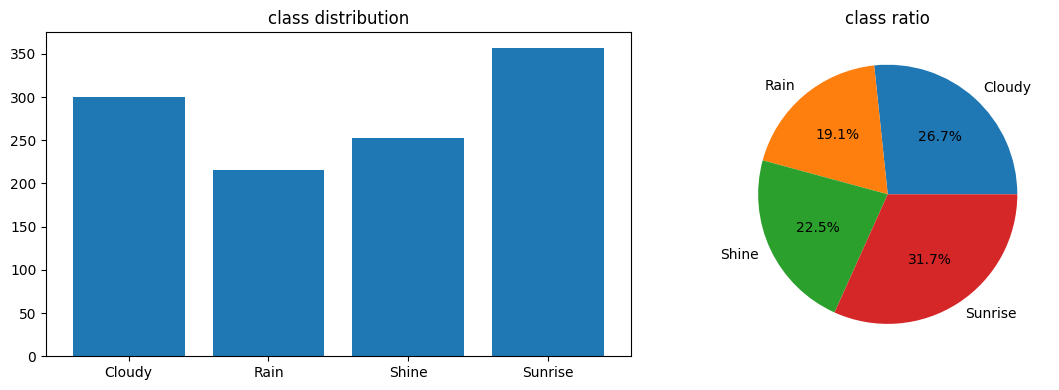

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.keys(), counts.values())
axes[0].set_title('class distribution')

axes[1].pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%')
axes[1].set_title('class ratio')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

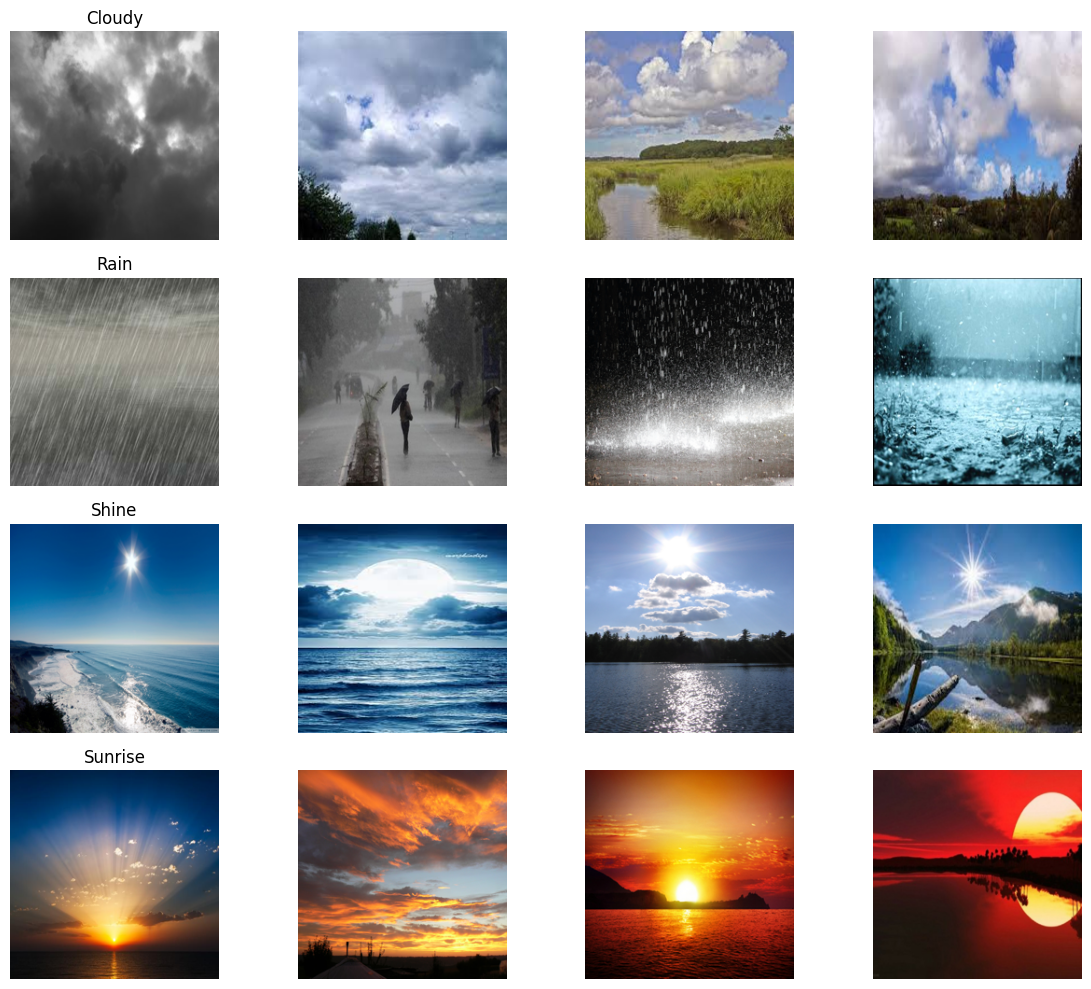

In [17]:
fig, axes = plt.subplots(len(categories), 4, figsize=(12, len(categories) * 2.5))

for row, cat in enumerate(categories):
    paths = sorted((data_dir / cat).glob('*.*'))[:4]
    for col, p in enumerate(paths):
        img = np.array(Image.open(p).convert('RGB').resize((224, 224)))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cat)

plt.tight_layout()
plt.savefig('samples.png', dpi=150)
plt.show()

## Data cleaning

checking for corrupted files.

In [18]:
bad = []
for cat in categories:
    for p in (data_dir / cat).glob('*.*'):
        try:
            Image.open(p).verify()
        except:
            bad.append(p)

print(f'{len(bad)} corrupted files')

0 corrupted files


## Dataloader

In [19]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [20]:
class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label


base = ImageFolder(data_dir)
class_names = base.classes
n_val = int(len(base) * 0.2)

train_idx, val_idx = random_split(
    range(len(base)), [len(base) - n_val, n_val],
    generator=torch.Generator().manual_seed(seed)
)

train_ds = SubsetWithTransform(base, train_idx, train_tf)
val_ds   = SubsetWithTransform(base, val_idx,   val_tf)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)

print(f'train: {len(train_ds)}, val: {len(val_ds)}')
print('classes:', class_names)

train: 900, val: 225
classes: ['Cloudy', 'Rain', 'Shine', 'Sunrise']


### Model

efficientnet-b0 pretrained on imagenet, replacing the classifier head

In [21]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, len(class_names))
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


## Training

In [22]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        total_loss += criterion(out, labels).item() * len(imgs)
        correct += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [23]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

for epoch in range(10):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(history, [tr_acc, vl_acc, tr_loss, vl_loss]):
        history[k].append(v)
    print(f'epoch {epoch+1:2d} | loss {tr_loss:.3f} | acc {tr_acc*100:.1f}% | val {vl_acc*100:.1f}%')

epoch  1 | loss 0.935 | acc 69.9% | val 88.4%


epoch  2 | loss 0.630 | acc 88.8% | val 87.6%


epoch  3 | loss 0.581 | acc 89.6% | val 90.2%


epoch  4 | loss 0.540 | acc 92.3% | val 90.7%


epoch  5 | loss 0.532 | acc 92.4% | val 90.2%


epoch  6 | loss 0.535 | acc 92.3% | val 91.1%


epoch  7 | loss 0.491 | acc 95.8% | val 92.0%


epoch  8 | loss 0.509 | acc 94.8% | val 90.2%


epoch  9 | loss 0.501 | acc 95.2% | val 91.1%


epoch 10 | loss 0.497 | acc 95.3% | val 91.1%


In [24]:
for name, p in model.named_parameters():
    if 'features.7' in name or 'features.8' in name or 'classifier' in name:
        p.requires_grad = True

optimizer2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=8)

for epoch in range(8):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer2)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler2.step()
    for k, v in zip(history, [tr_acc, vl_acc, tr_loss, vl_loss]):
        history[k].append(v)
    print(f'finetune {epoch+1:2d} | loss {tr_loss:.3f} | acc {tr_acc*100:.1f}% | val {vl_acc*100:.1f}%')

finetune  1 | loss 0.491 | acc 94.9% | val 90.7%


finetune  2 | loss 0.502 | acc 94.9% | val 92.0%


finetune  3 | loss 0.505 | acc 94.1% | val 92.0%


finetune  4 | loss 0.485 | acc 95.6% | val 92.4%


finetune  5 | loss 0.486 | acc 95.2% | val 91.6%


finetune  6 | loss 0.477 | acc 96.6% | val 89.8%


finetune  7 | loss 0.478 | acc 96.7% | val 92.9%


finetune  8 | loss 0.485 | acc 95.3% | val 91.1%


## Results

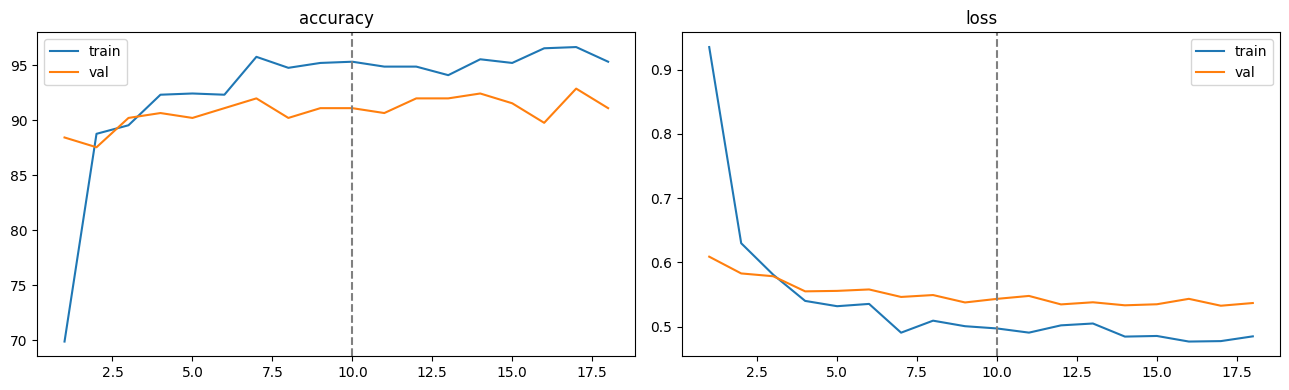

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = range(1, len(history['train_acc']) + 1)

axes[0].plot(x, [v*100 for v in history['train_acc']], label='train')
axes[0].plot(x, [v*100 for v in history['val_acc']],   label='val')
axes[0].axvline(x=10, color='gray', linestyle='--')
axes[0].set_title('accuracy')
axes[0].legend()

axes[1].plot(x, history['train_loss'], label='train')
axes[1].plot(x, history['val_loss'],   label='val')
axes[1].axvline(x=10, color='gray', linestyle='--')
axes[1].set_title('loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [26]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      Cloudy       0.88      0.82      0.85        55
        Rain       0.97      0.97      0.97        39
       Shine       0.85      0.85      0.85        54
     Sunrise       0.94      0.99      0.96        77

    accuracy                           0.91       225
   macro avg       0.91      0.91      0.91       225
weighted avg       0.91      0.91      0.91       225



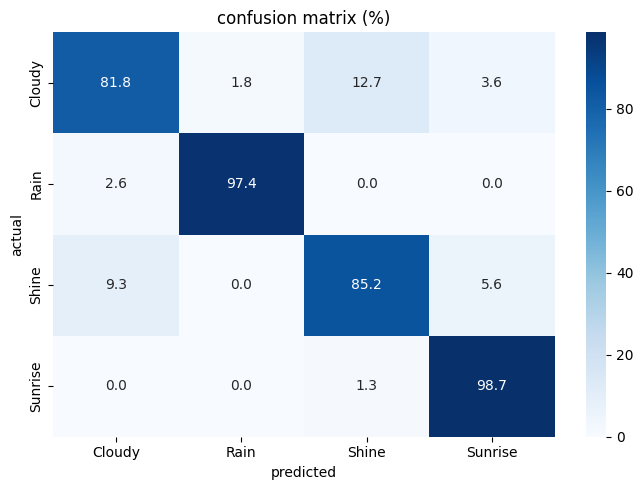

In [27]:
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(7, 5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix (%)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Grad-CAM

Visualizing what the model focuses on

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


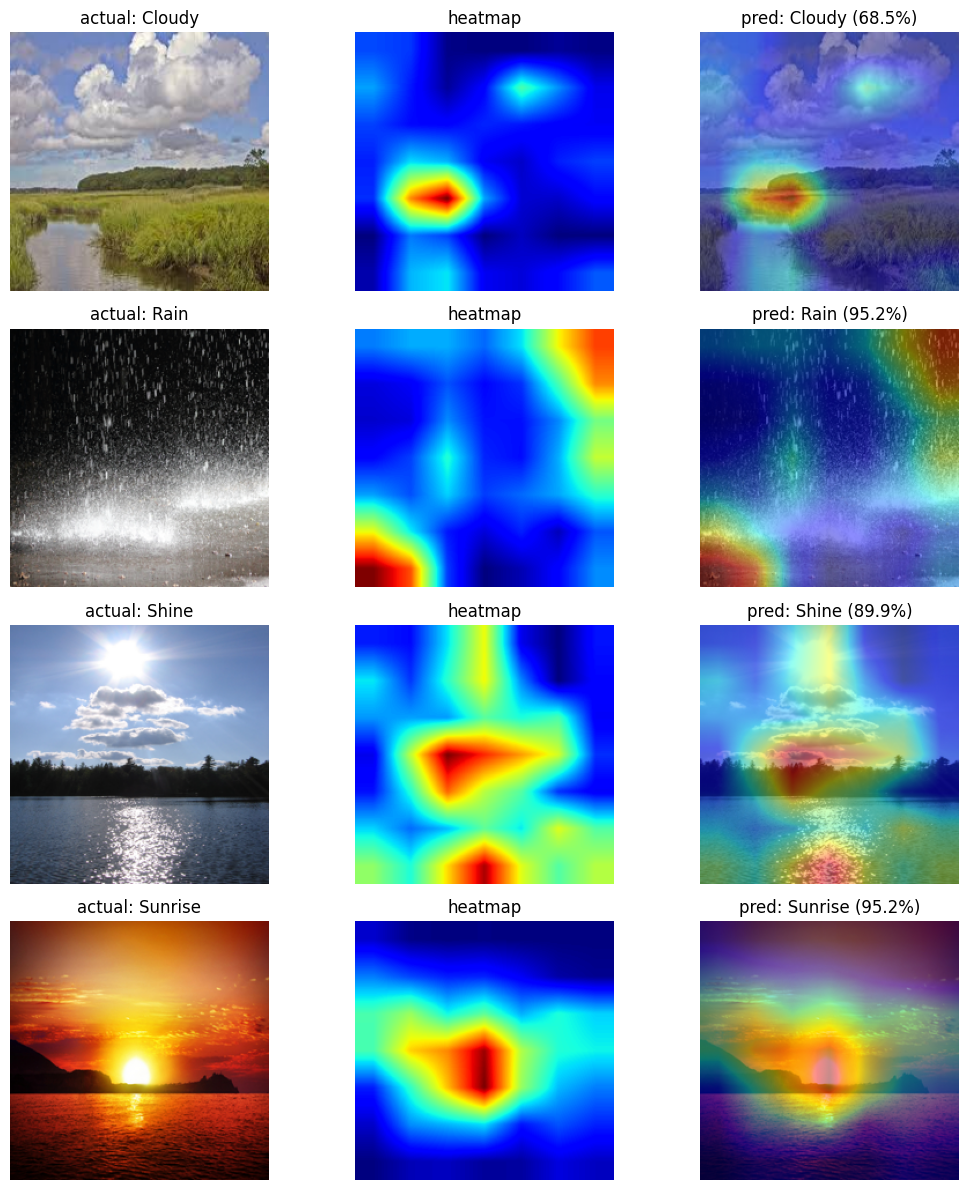

In [28]:
class GradCAM:
    def __init__(self, model, layer):
        self.acts = None
        self.grads = None
        self.model = model
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        layer.register_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        idx = out.argmax(1).item()
        out[0, idx].backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1)).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (img_size, img_size))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        conf = torch.softmax(out, 1)[0, idx].item()
        return cam, idx, conf


gradcam = GradCAM(model, model.features[-1])

fig, axes = plt.subplots(len(categories), 3, figsize=(11, len(categories) * 3))

for row, cat in enumerate(categories):
    p = sorted((data_dir / cat).glob('*.*'))[2]
    pil = Image.open(p).convert('RGB').resize((img_size, img_size))
    img_np = np.array(pil) / 255.0
    tensor = val_tf(pil).unsqueeze(0).to(device)

    cam, pred_idx, conf = gradcam(tensor)
    overlay = (img_np * 0.55 + mpl_cm.jet(cam)[:, :, :3] * 0.45).clip(0, 1)

    axes[row][0].imshow(img_np)
    axes[row][0].set_title(f'actual: {cat}')
    axes[row][1].imshow(cam, cmap='jet')
    axes[row][1].set_title('heatmap')
    axes[row][2].imshow(overlay)
    axes[row][2].set_title(f'pred: {class_names[pred_idx]} ({conf*100:.1f}%)')
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150)
plt.show()

In [29]:
torch.save({'state_dict': model.state_dict(), 'classes': class_names}, 'model.pth')
print('model saved')

saved.
